In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
df = pd.read_csv("/Users/athipongjindaphram/Documents/Python For Data Analyst/data_jobs.csv")
#Cleaning Date Column -> Type : Date time
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [20]:
df_us = df[df["job_country"] == "United States"].dropna(subset="salary_year_avg")


In [21]:
job_titles = df_us["job_title_short"].value_counts().index[:6].tolist()

In [22]:
df_us_top6 = df_us[
    df_us["job_title_short"]
    .isin(job_titles)
    ]

In [23]:
job_order = df_us_top6.groupby("job_title_short")["salary_year_avg"].median().sort_values(ascending=False).index

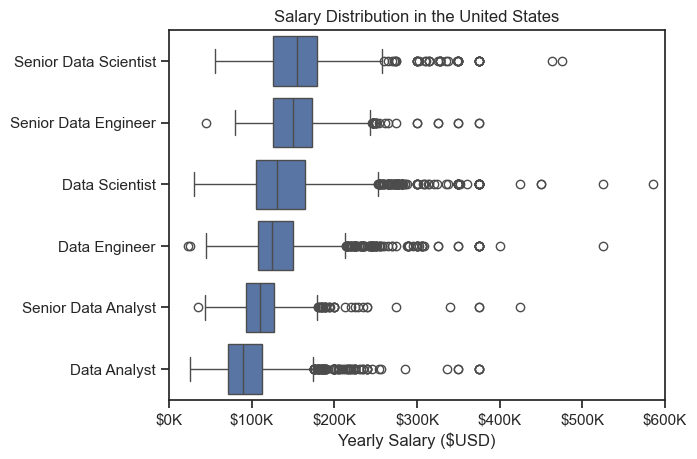

In [25]:
sns.boxplot(data=df_us_top6, x="salary_year_avg", y="job_title_short", order=job_order)
sns.set_theme(style="ticks")

plt.title("Salary Distribution in the United States")
plt.xlabel("Yearly Salary ($USD)")
plt.ylabel("")
plt.xlim(0,600000)

ticks_x = plt.FuncFormatter(lambda y, pos: f"${int(y/1000)}K")
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()